In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv('../data/employee_attrition.csv')
data.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
df = data.copy()

In [4]:
df.shape
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 1470
Number of columns: 35


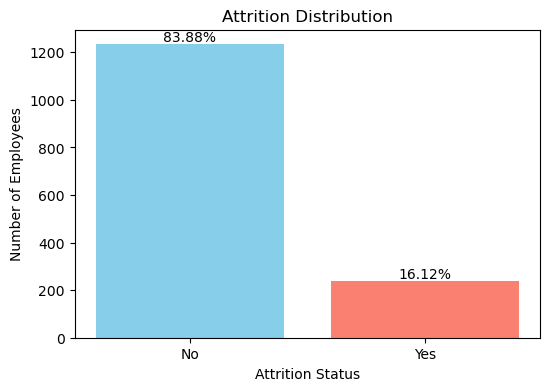

In [5]:

counts = df['Attrition'].value_counts()
percentages = counts / len(df) * 100


plt.figure(figsize=(6,4))
bars = plt.bar(counts.index, counts.values, color=['skyblue','salmon'])

for bar, pct in zip(bars, percentages.round(2)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{pct:.2f}%', ha='center', va='bottom', fontsize=10)

plt.title("Attrition Distribution")
plt.ylabel("Number of Employees")
plt.xlabel("Attrition Status")
plt.show()


- The attrition rate in this dataset is clearly **imbalanced**, with 83.88% of employees staying and only 16.12% leaving. This means the majority class (“No Attrition”) dominates the data, while the minority class (“Yes Attrition”) is underrepresented. Such imbalance can cause predictive models to favor the majority class, leading to misleadingly high accuracy but poor detection of actual attrition cases. To address this, techniques like resampling, adjusting class weights, or using evaluation metrics beyond accuracy (such as F1‑score or ROC‑AUC) are essential to ensure fair and meaningful insights.

In [6]:
categorical_features = df.select_dtypes(include=['object']).columns
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Features:" , len(categorical_features))
print("\nNumeric Features:" , len(numeric_features))

Categorical Features: 9

Numeric Features: 26


In [7]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [9]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [10]:
# Checking for missing values
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [11]:
# Duplicated Values
df.duplicated().sum()

np.int64(0)

In [12]:
def treat_outliers(df, cols, method="median"):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        if method == "median":
            median = df[col].median()
            # Cast to int if column is int64
            if pd.api.types.is_integer_dtype(df[col]):
                median = int(median)
            df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col] = median
        elif method == "mean":
            mean = df[col].mean()
            if pd.api.types.is_integer_dtype(df[col]):
                mean = int(mean)
            df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col] = mean
        elif method == "cap":
            df.loc[df[col] < lower_bound, col] = lower_bound
            df.loc[df[col] > upper_bound, col] = upper_bound
    return df


# Example usage:
df_cleaned = treat_outliers(df, numeric_features, method="median")

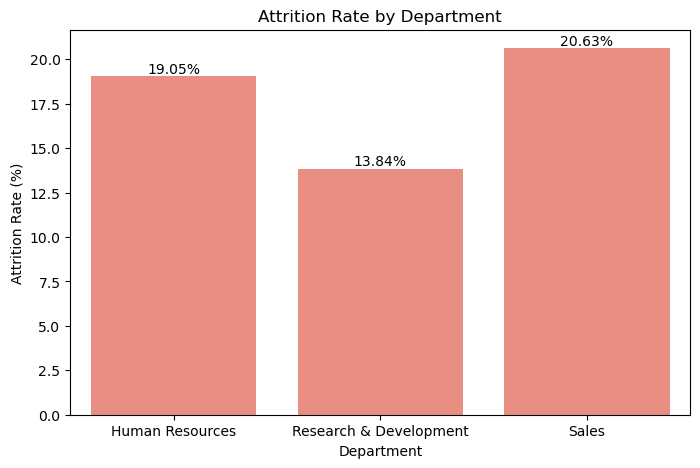

In [13]:
# Calculate attrition rate (%) by department
attrition_rate = df.groupby('Department')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).reset_index()

plt.figure(figsize=(8,5))
ax = sns.barplot(x='Department', y='Attrition', data=attrition_rate, color='salmon')

# Annotate each bar with its value
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black')

plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Department")
plt.show()

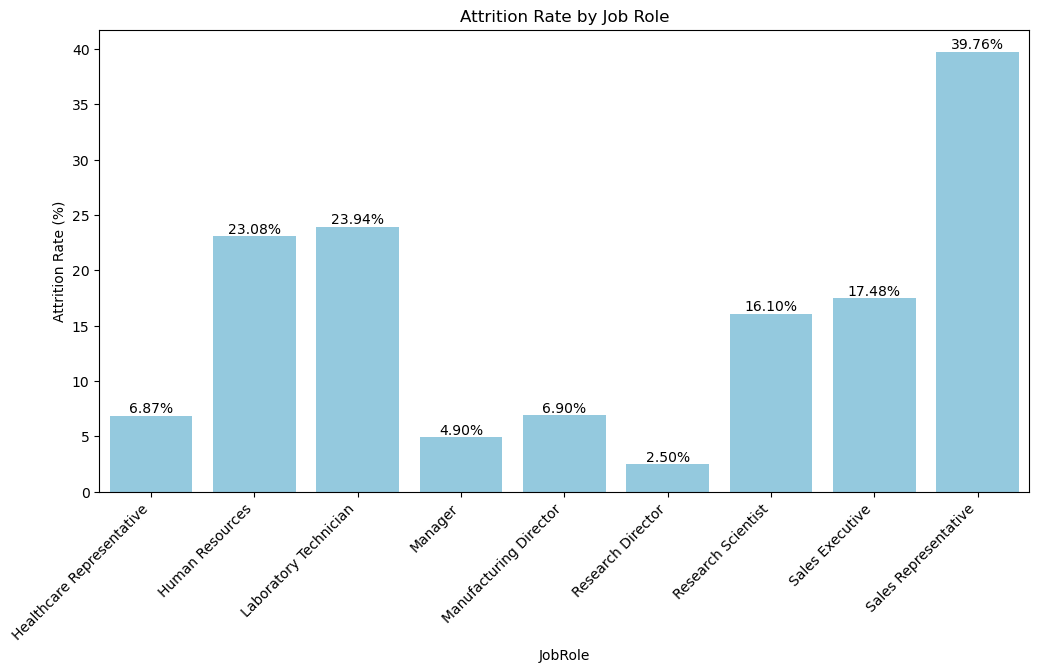

In [14]:
# Calculate attrition rate (%) by Job Role
attrition_rate_role = df.groupby('JobRole')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).reset_index()

plt.figure(figsize=(12,6))
ax = sns.barplot(x='JobRole', y='Attrition', data=attrition_rate_role, color='skyblue')

# Annotate each bar with its percentage value
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black')

plt.xticks(rotation=45, ha='right')
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Job Role")
plt.show()

C:\Users\alokp\AppData\Local\Temp\ipykernel_12856\3976328241.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_income = df.groupby('IncomeBin')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).reset_index()


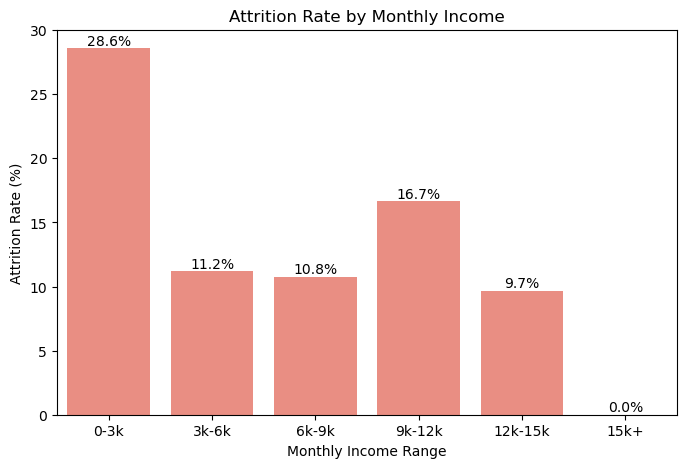

In [15]:
# Create income bins for clearer comparison
df['IncomeBin'] = pd.cut(df['MonthlyIncome'],
                         bins=[0, 3000, 6000, 9000, 12000, 15000, df['MonthlyIncome'].max()],
                         labels=['0-3k','3k-6k','6k-9k','9k-12k','12k-15k','15k+'])

# Calculate attrition rate (%) per income bin
attrition_income = df.groupby('IncomeBin')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).reset_index()

# Plot bar chart
plt.figure(figsize=(8,5))
ax = sns.barplot(x='IncomeBin', y='Attrition', data=attrition_income, color='salmon')

# Annotate percentages
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black')

plt.ylabel("Attrition Rate (%)")
plt.xlabel("Monthly Income Range")
plt.title("Attrition Rate by Monthly Income")
plt.show()


C:\Users\alokp\AppData\Local\Temp\ipykernel_12856\474162844.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette="Set2")


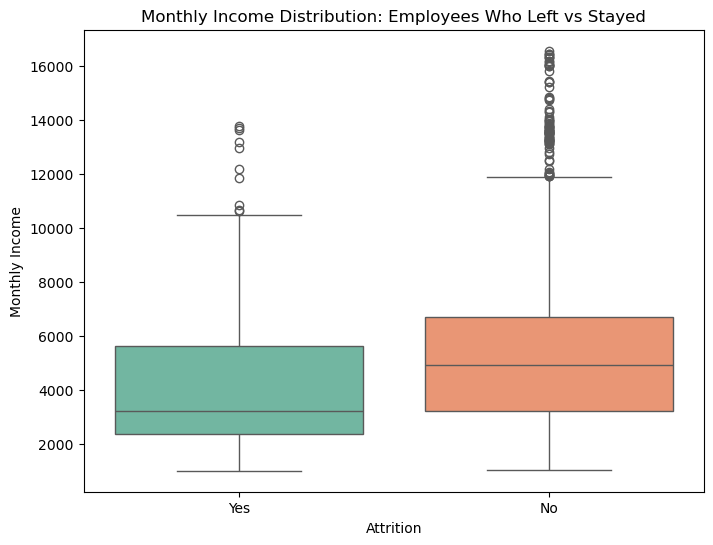

In [16]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette="Set2")

plt.title("Monthly Income Distribution: Employees Who Left vs Stayed")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

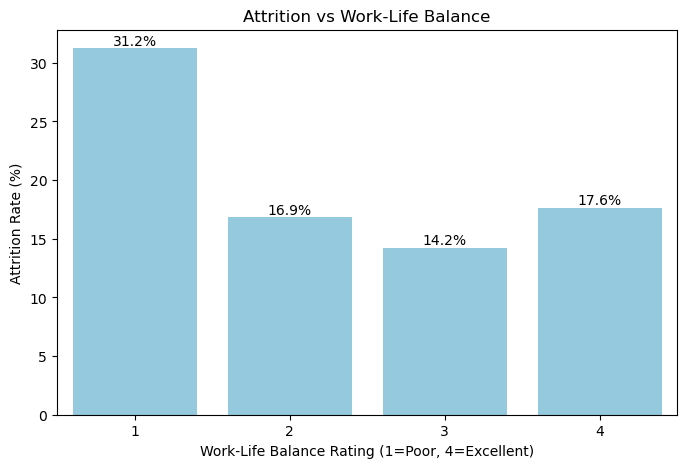

In [17]:
# Calculate attrition rate (%) by Work-Life Balance rating
attrition_wlb = df.groupby('WorkLifeBalance')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).reset_index()

plt.figure(figsize=(8,5))
ax = sns.barplot(x='WorkLifeBalance', y='Attrition', data=attrition_wlb, color='skyblue')

# Annotate each bar with its percentage value
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black')

plt.xlabel("Work-Life Balance Rating (1=Poor, 4=Excellent)")
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition vs Work-Life Balance")
plt.show()

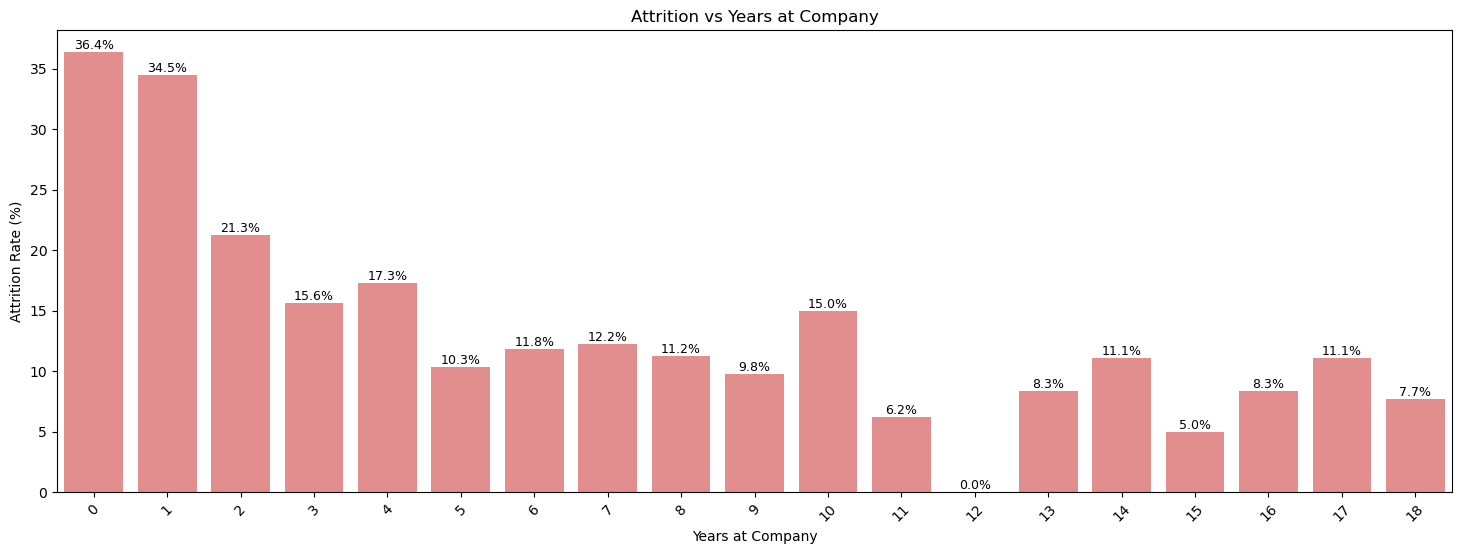

In [18]:
# Calculate attrition rate (%) by YearsAtCompany
attrition_years = df.groupby('YearsAtCompany')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).reset_index()

plt.figure(figsize=(18,6))
ax = sns.barplot(x='YearsAtCompany', y='Attrition', data=attrition_years, color='lightcoral')

# Annotate each bar with its percentage value
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', fontsize=9, color='black')

plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition vs Years at Company")
plt.xticks(rotation=45)
plt.show()

In [19]:
df = df.drop(['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours', 'DailyRate', 'HourlyRate', 'MonthlyRate', ], axis=1)
df.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,IncomeBin
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,3,...,1,0,8,3,1,6,4,0,5,3k-6k
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,2,...,4,1,10,3,3,10,7,1,7,3k-6k
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,4,Male,2,...,2,0,7,3,3,0,0,0,0,0-3k
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,3,...,3,0,8,3,3,8,7,3,0,0-3k
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,Male,3,...,4,1,6,3,3,2,2,2,2,3k-6k


In [20]:
# Save DataFrame to CSV
df.to_csv('../data/cleaned_employee_attrition.csv', index=False)
